In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

from code_descriptors_postural_control.stabilogram.stato import Stabilogram
from code_descriptors_postural_control.descriptors import compute_all_features

In [168]:
# df = pd.read_csv("../data/antoine/radar24/test3.csv")
df = pd.read_csv("../data/kelly/X_vitesse.csv")
X_time = df["Time_s"].values
X_velocity = df["Vmax_m_s"].values
X0 = -5
X_position = cumulative_trapezoid(X_velocity, X_time, initial=0)
x_pos = X_position


# df = pd.read_csv("../data/antoine/radar9/test3.csv")
df = pd.read_csv("../data/kelly/Y_vitesse.csv")
Y_time = df["Time_s"].values
Y_velocity = df["Vmax_m_s"].values
Y0 = 25
Y_position = cumulative_trapezoid(Y_velocity, Y_time, initial=0)
y_pos = Y_position

In [169]:
x_pos = x_pos*1000
y_pos = y_pos*1000

In [170]:
1/X_time[1]

np.float64(17.20000000000001)

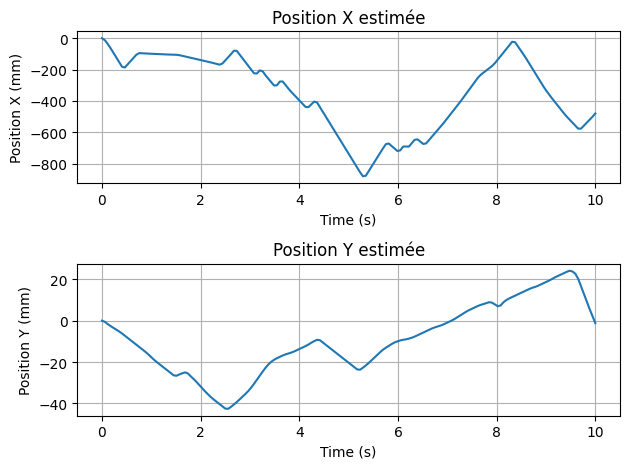

In [171]:

plt.figure()

# Plot X
plt.subplot(2, 1, 1)
plt.plot(X_time, x_pos)
plt.xlabel("Time (s)")
plt.ylabel("Position X (mm)")
plt.title("Position X estimée")
plt.grid()

# Plot Y
plt.subplot(2, 1, 2)
plt.plot(Y_time, y_pos)
plt.xlabel("Time (s)")
plt.ylabel("Position Y (mm)")
plt.title("Position Y estimée")
plt.grid()

plt.tight_layout()
plt.show()


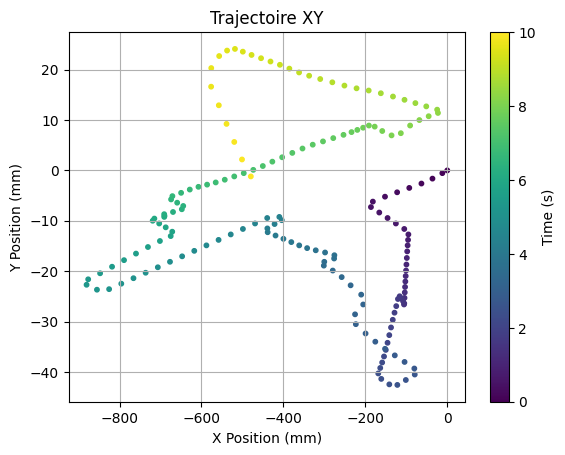

In [172]:

plt.figure()
sc = plt.scatter(x_pos, y_pos, c=Y_time, cmap='viridis', s=10)
plt.xlabel("X Position (mm)")
plt.ylabel("Y Position (mm)")
plt.title("Trajectoire XY")
plt.grid()

cbar = plt.colorbar(sc)
cbar.set_label("Time (s)")
plt.show()

# Centering

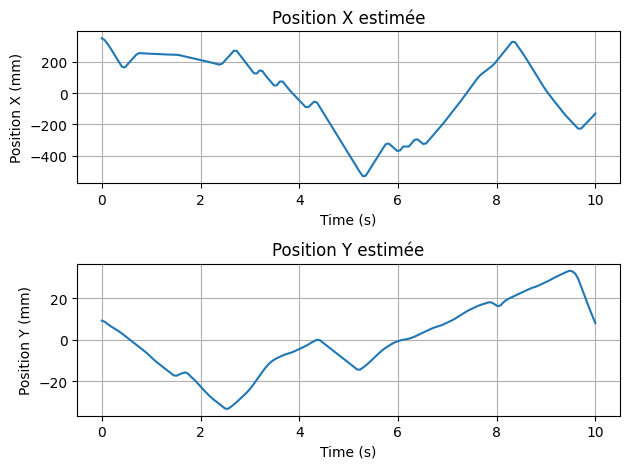

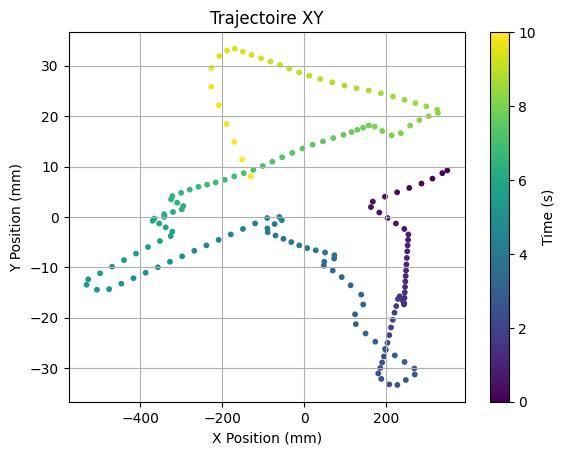

In [173]:
x_pos = x_pos - np.mean(x_pos)
y_pos = y_pos - np.mean(y_pos)

# Plot X
plt.subplot(2, 1, 1)
plt.plot(Y_time, x_pos)
plt.xlabel("Time (s)")
plt.ylabel("Position X (mm)")
plt.title("Position X estimée")
plt.grid()

# Plot Y
plt.subplot(2, 1, 2)
plt.plot(Y_time, y_pos)
plt.xlabel("Time (s)")
plt.ylabel("Position Y (mm)")
plt.title("Position Y estimée")
plt.grid()

plt.tight_layout()
plt.show()

plt.figure()
sc = plt.scatter(x_pos, y_pos, c=Y_time, cmap='viridis', s=10)
plt.xlabel("X Position (mm)")
plt.ylabel("Y Position (mm)")
plt.title("Trajectoire XY")
plt.grid()

cbar = plt.colorbar(sc)
cbar.set_label("Time (s)")
plt.show()

In [174]:
x = x_pos - np.mean(x_pos)
y = y_pos - np.mean(y_pos)

modulus = np.sqrt(x**2 + y**2)
angle = np.arctan2(y, x)

modulus95 = modulus[modulus <= np.percentile(modulus, 95)]
rmax = np.max(modulus95)

mod_norm = modulus / rmax
x_norm = mod_norm * np.cos(angle)
y_norm = mod_norm * np.sin(angle)

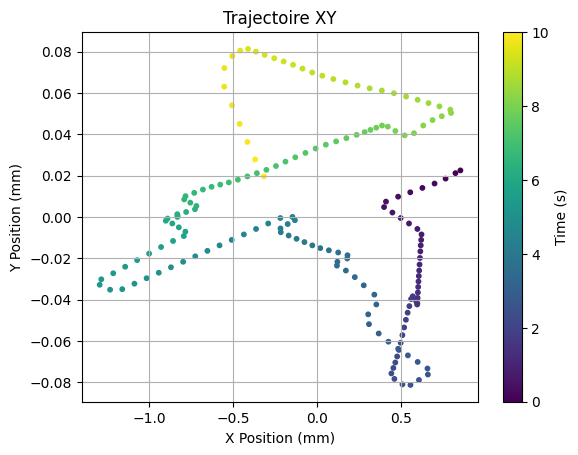

In [175]:
plt.figure()
sc = plt.scatter(x_norm, y_norm, c=Y_time, cmap='viridis', s=10)
plt.xlabel("X Position (mm)")
plt.ylabel("Y Position (mm)")
plt.title("Trajectoire XY")
plt.grid()

cbar = plt.colorbar(sc)
cbar.set_label("Time (s)")
plt.show()

In [176]:
data = np.array([x_pos/10, y_pos/10]).T

stato = Stabilogram()
stato.from_array(array=data, original_frequency=1/Y_time[1])

C:\Users\Kelly\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 250 is greater than input length  = 245, using nperseg = 245
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


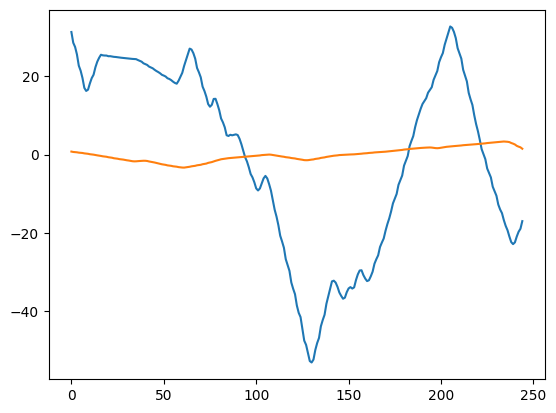

In [177]:
sway_density_radius = 0.3 # 3 mm
params_dic = {"sway_density_radius": sway_density_radius}
features = compute_all_features(stato, params_dic=params_dic)

plt.plot(stato.medio_lateral)
plt.plot(stato.antero_posterior)

In [178]:
features 

{'mean_value_ML': np.float64(3.4500340927080008e-15),
 'mean_value_AP': np.float64(-1.630038429218438e-16),
 'mean_distance_ML': np.float64(20.899147932989813),
 'mean_distance_AP': np.float64(1.4070383129596324),
 'mean_distance_Radius': np.float64(21.030319924562157),
 'maximal_distance_ML': np.float64(53.18356716736743),
 'maximal_distance_AP': np.float64(3.338201985625643),
 'maximal_distance_Radius': np.float64(53.19930212532553),
 'rms_ML': np.float64(23.830867335785932),
 'rms_AP': np.float64(1.7190543363798774),
 'rms_Radius': np.float64(23.892789409929836),
 'range_ML': np.float64(85.94287735534385),
 'range_AP': np.float64(6.6763889321811485),
 'range_ML_AND_AP': np.float64(86.00862738279098),
 'range_ratio_ML_AND_AP': np.float64(12.872658892157542),
 'planar_deviation_ML_AND_AP': np.float64(23.892789409929836),
 'coefficient_sway_direction_ML_AND_AP': np.float64(-0.12354477244013921),
 'confidence_ellipse_area_ML_AND_AP': np.float64(781.0700559351145),
 'principal_sway_direc